In [25]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",100)

In [26]:
master = pd.read_csv("../data/final/master_dataset_featured.csv")

print(master.shape)

master.head()

(345374, 40)


,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield,Start_Year,Year_yield,Area_yield,Production_yield,fertilizer,pesticide,Yield_yield,Year_weather,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH,End_Year,Decade,Year_Group,Rainfall_Category,Temperature_Category,Humidity_Category,Production_per_Hectare,Fertilizer_per_Hectare,Pesticide_per_Hectare,Rainfall_per_Hectare,Crop_Category,Production_Level,Yield_Level,Weather_Data_Available,Soil_Data_Available
0,Andaman And Nicobar Islands,Nicobars,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2002,2000,2001-2005,NaN,NaN,NaN,1.643541,NaN,NaN,NaN,Other,Medium,Medium,False,False
1,Andaman And Nicobar Islands,Nicobars,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,2000,2001-2005,NaN,NaN,NaN,1.655803,NaN,NaN,NaN,Other,Medium,Medium,False,False
2,Andaman And Nicobar Islands,Nicobars,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004,2000,2001-2005,NaN,NaN,NaN,1.209358,NaN,NaN,NaN,Other,Medium,Medium,False,False
3,Andaman And Nicobar Islands,North And Middle Andaman,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2002,2000,2001-2005,NaN,NaN,NaN,1.690000,NaN,NaN,NaN,Other,High,Medium,False,False
4,Andaman And Nicobar Islands,South Andamans,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,2000,2001-2005,NaN,NaN,NaN,1.696296,NaN,NaN,NaN,Other,High,Medium,False,False


In [27]:
print("="*70)
print("PHASE 8 : BUSINESS INSIGHTS ANALYSIS")
print("="*70)

PHASE 8 : BUSINESS INSIGHTS ANALYSIS


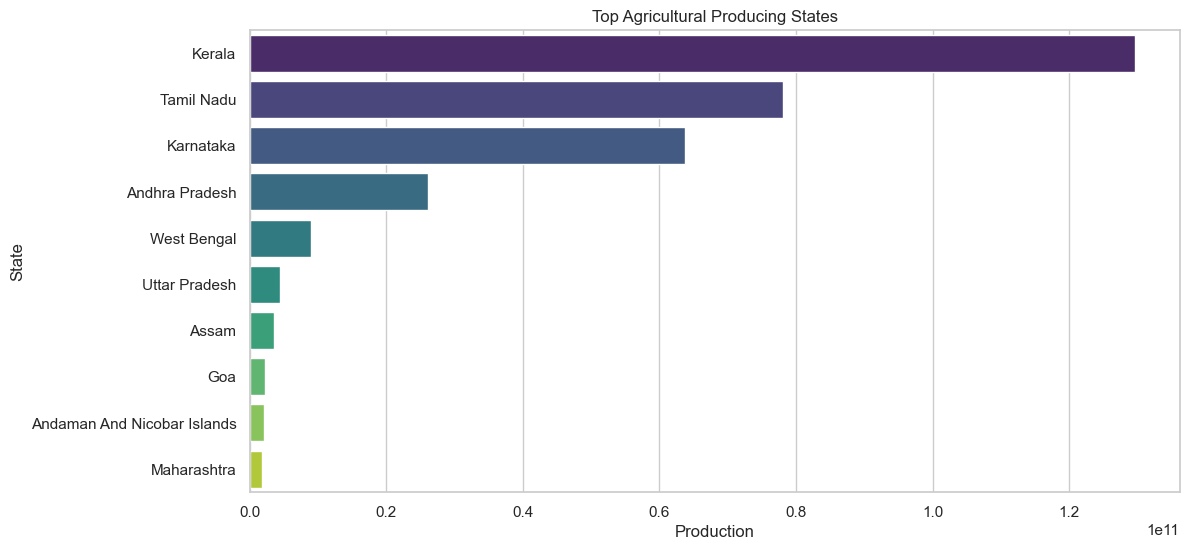

In [28]:
top_states = (
    master.groupby("State")["Production"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index,
    palette="viridis"
)

plt.title("Top Agricultural Producing States")

plt.xlabel("Production")

plt.ylabel("State")

plt.show()

In [29]:
display(top_states)

State
Kerala                         1.297006e+11
Tamil Nadu                     7.805176e+10
Karnataka                      6.377280e+10
Andhra Pradesh                 2.607622e+10
West Bengal                    8.941179e+09
Uttar Pradesh                  4.442585e+09
Assam                          3.637715e+09
Goa                            2.194004e+09
Andaman And Nicobar Islands    2.053355e+09
Maharashtra                    1.878565e+09
Name: Production, dtype: float64

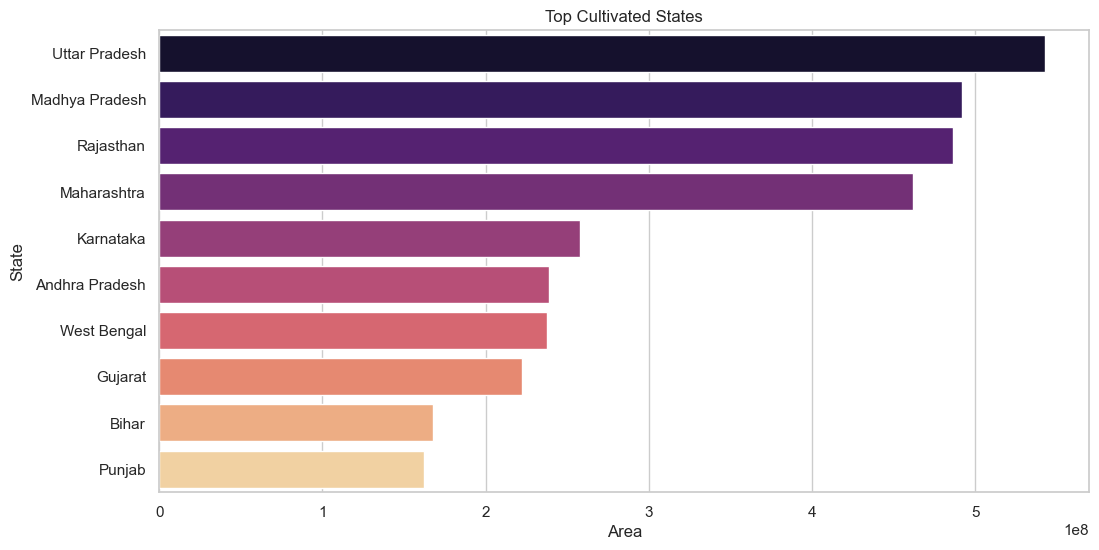

In [30]:
top_area = (
    master.groupby("State")["Area"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_area.values,
    y=top_area.index,
    palette="magma"
)

plt.title("Top Cultivated States")

plt.xlabel("Area")

plt.ylabel("State")

plt.show()

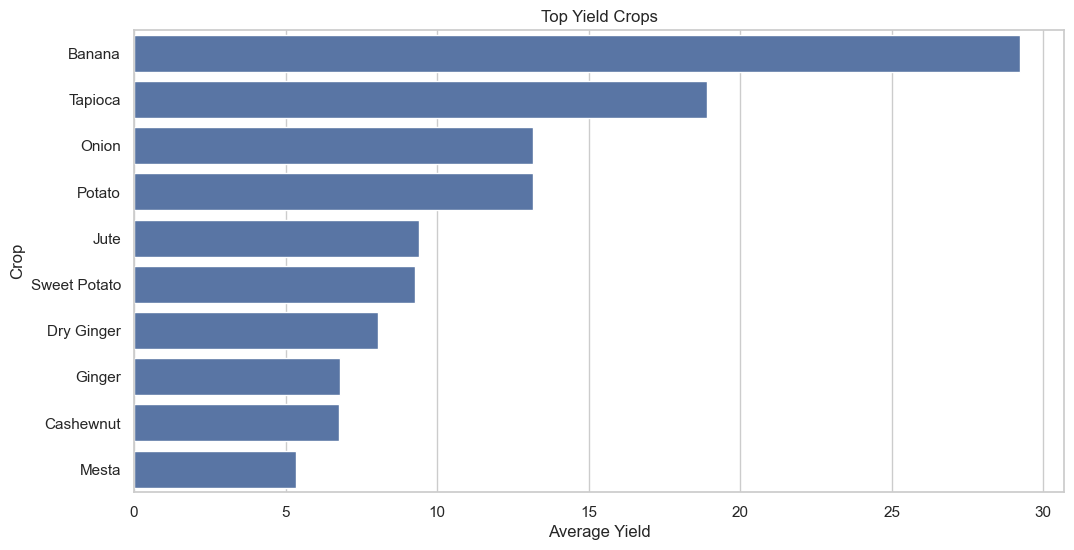

In [35]:
yield_crop = (
    master[
        (master["Crop"]!="Coconut")
        &
        (master["Crop"]!="Sugarcane")
    ]
    .groupby("Crop")["Yield"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=yield_crop.values,
    y=yield_crop.index,
)

plt.title("Top Yield Crops")

plt.xlabel("Average Yield")

plt.ylabel("Crop")

plt.show()

In [32]:
display(yield_crop)

Crop
Banana          29.227150
Tapioca         18.905036
Onion           13.178672
Potato          13.149256
Jute             9.387099
Sweet Potato     9.280331
Dry Ginger       8.052699
Ginger           6.793013
Cashewnut        6.762661
Mesta            5.351056
Name: Yield, dtype: float64

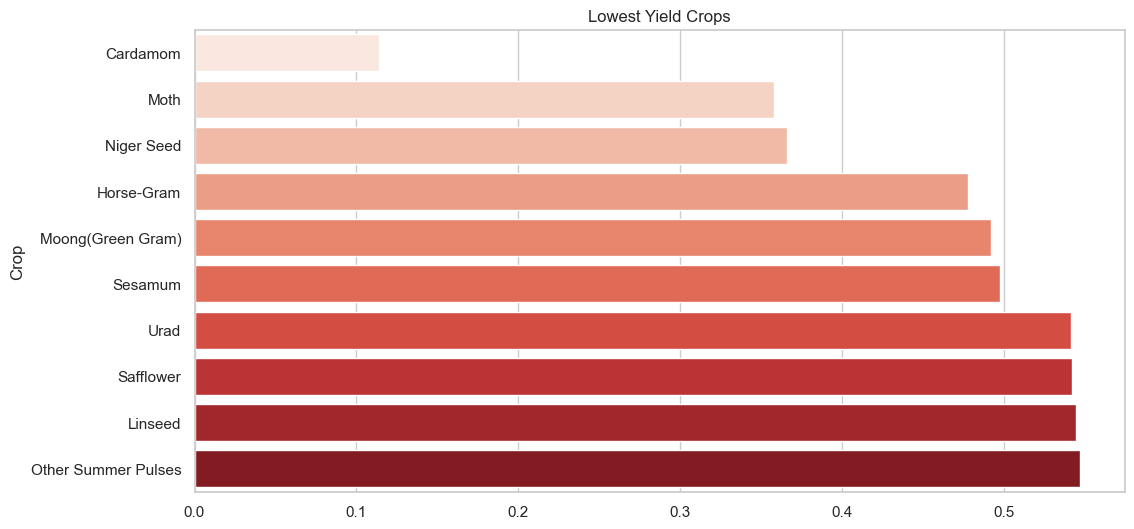

In [38]:
low_crop = (
    master.groupby("Crop")["Yield"]
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=low_crop.values,
    y=low_crop.index,
    palette="Reds"
)

plt.title("Lowest Yield Crops")

plt.show()

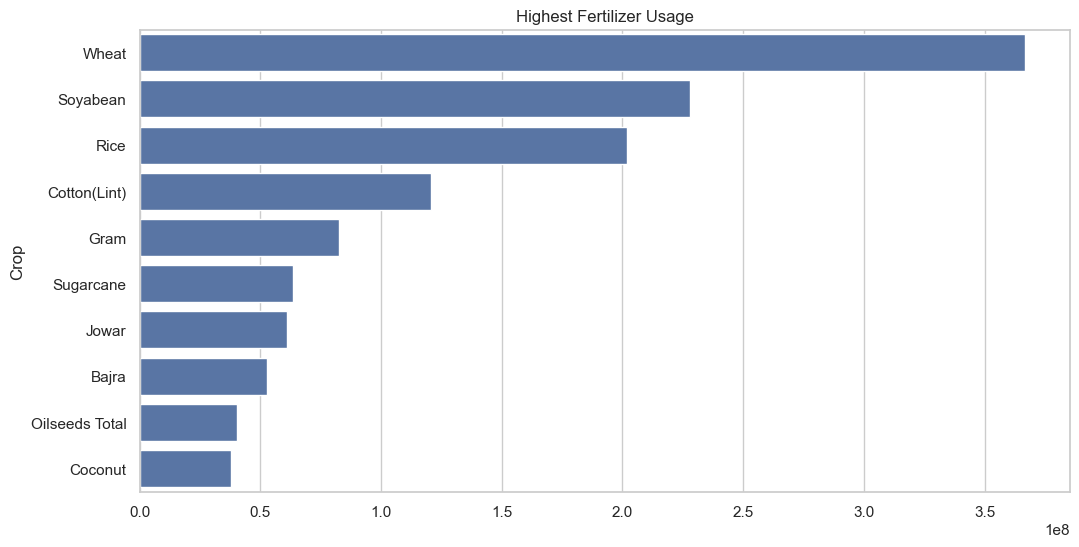

In [42]:
fert = (
    master.groupby("Crop")["fertilizer"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=fert.values,
    y=fert.index,
)

plt.title("Highest Fertilizer Usage")

plt.show()

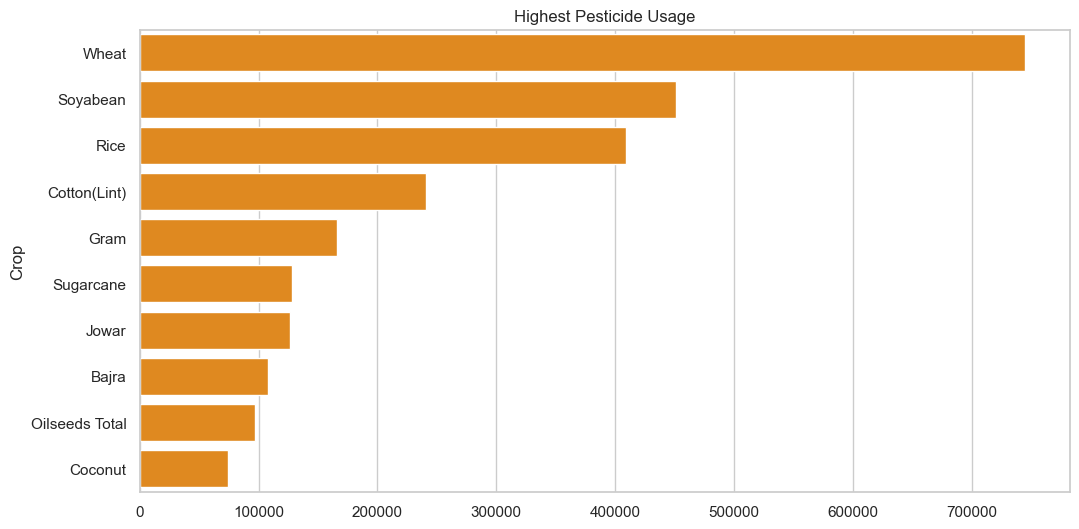

In [48]:

pest = (
    master.groupby("Crop")["pesticide"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=pest.values,
    y=pest.index,
    color="darkorange"
)

plt.title("Highest Pesticide Usage")

plt.show()

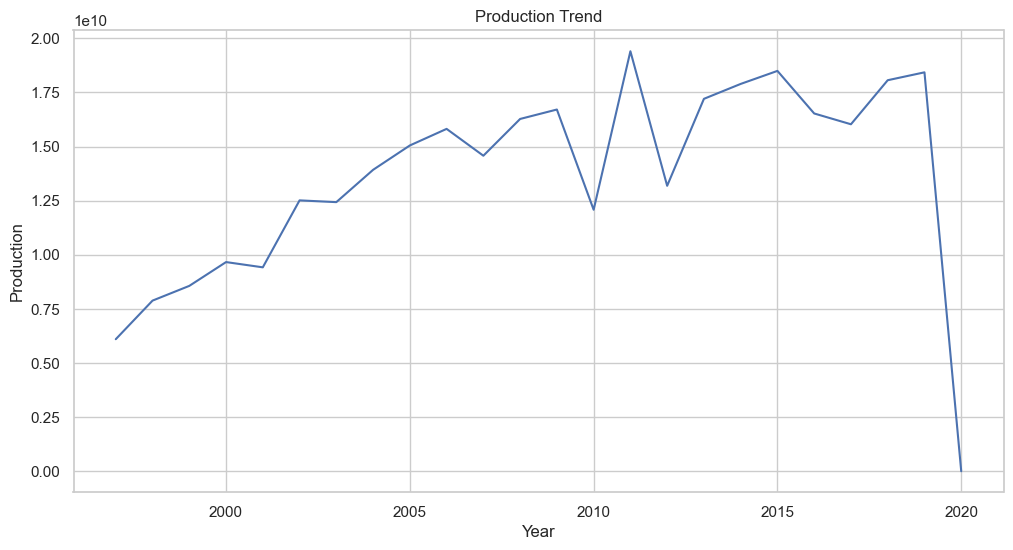

In [49]:
prod_trend = (
    master.groupby("Start_Year")["Production"]
    .sum()
)

plt.figure(figsize=(12,6))

plt.plot(prod_trend)

plt.title("Production Trend")

plt.xlabel("Year")

plt.ylabel("Production")

plt.show()

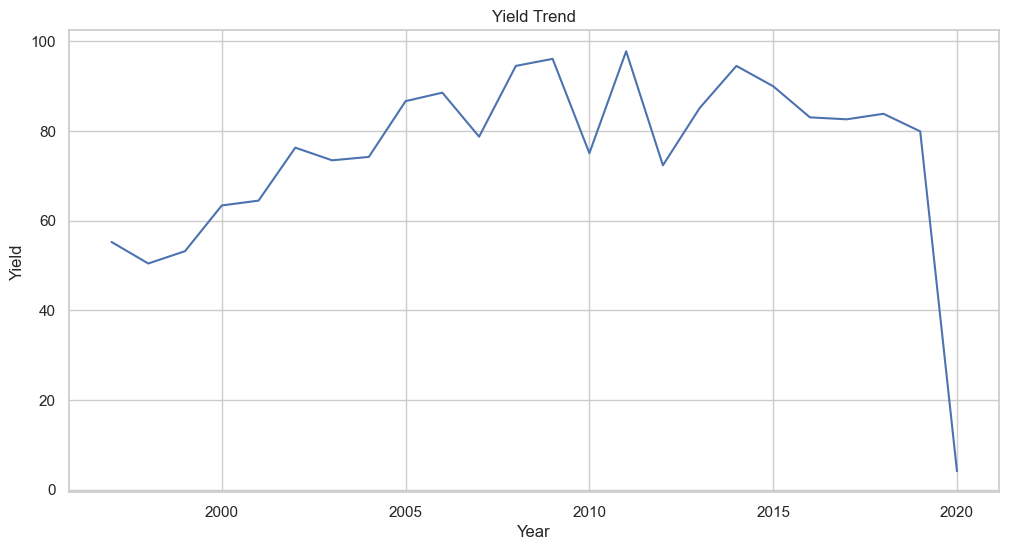

In [50]:
yield_trend = (
    master.groupby("Start_Year")["Yield"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(yield_trend)

plt.title("Yield Trend")

plt.xlabel("Year")

plt.ylabel("Yield")

plt.show()

In [51]:
# 8B CLIMATE ANALYSIS

In [52]:
weather = master.dropna(
    subset=[
        "avg_temp_c",
        "total_rainfall_mm",
        "avg_humidity_percent"
    ]
)

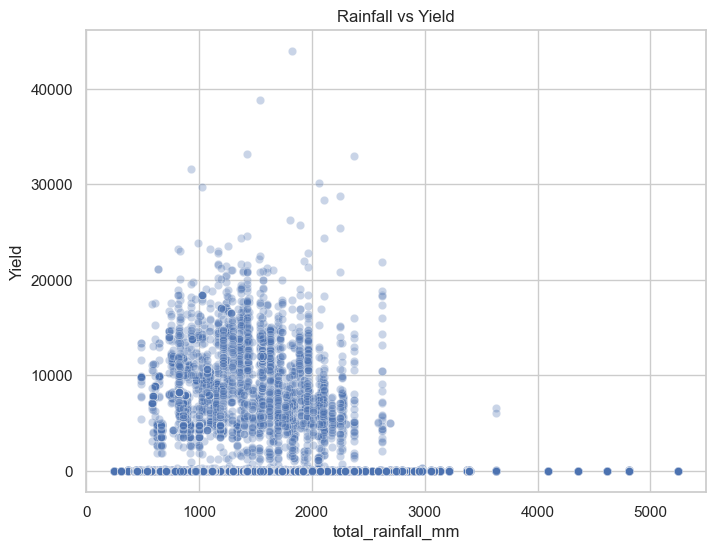

In [53]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=weather,
    x="total_rainfall_mm",
    y="Yield",
    alpha=.3
)

plt.title("Rainfall vs Yield")

plt.show()

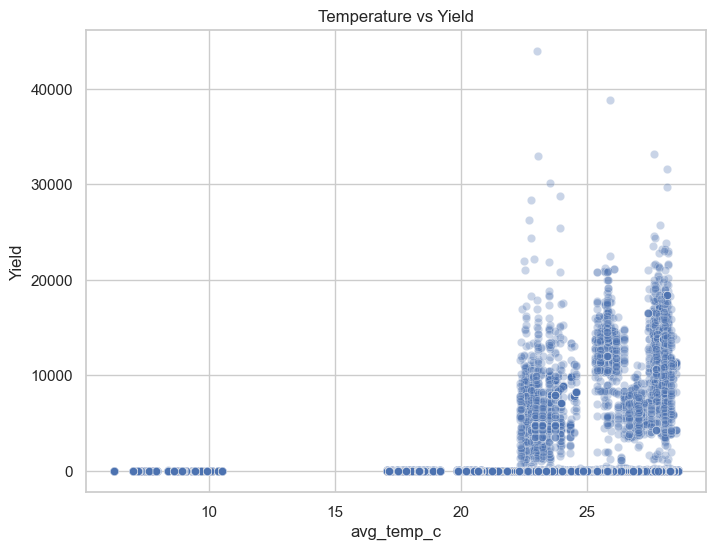

In [54]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=weather,
    x="avg_temp_c",
    y="Yield",
    alpha=.3
)

plt.title("Temperature vs Yield")

plt.show()

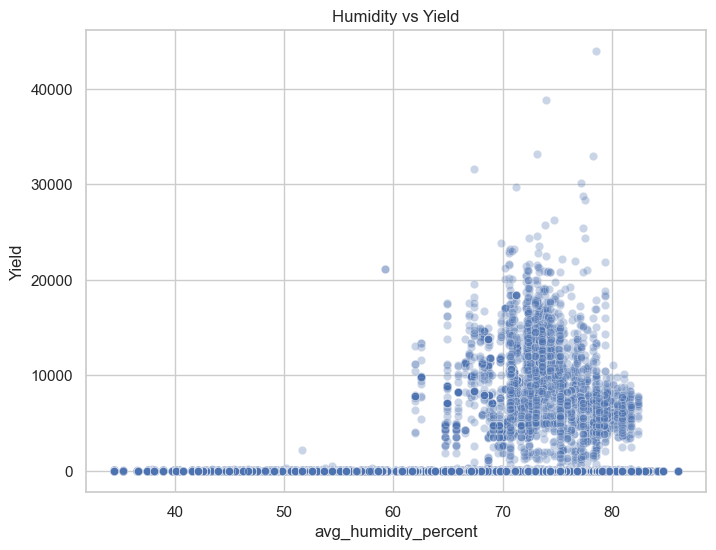

In [55]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=weather,
    x="avg_humidity_percent",
    y="Yield",
    alpha=.3
)

plt.title("Humidity vs Yield")

plt.show()

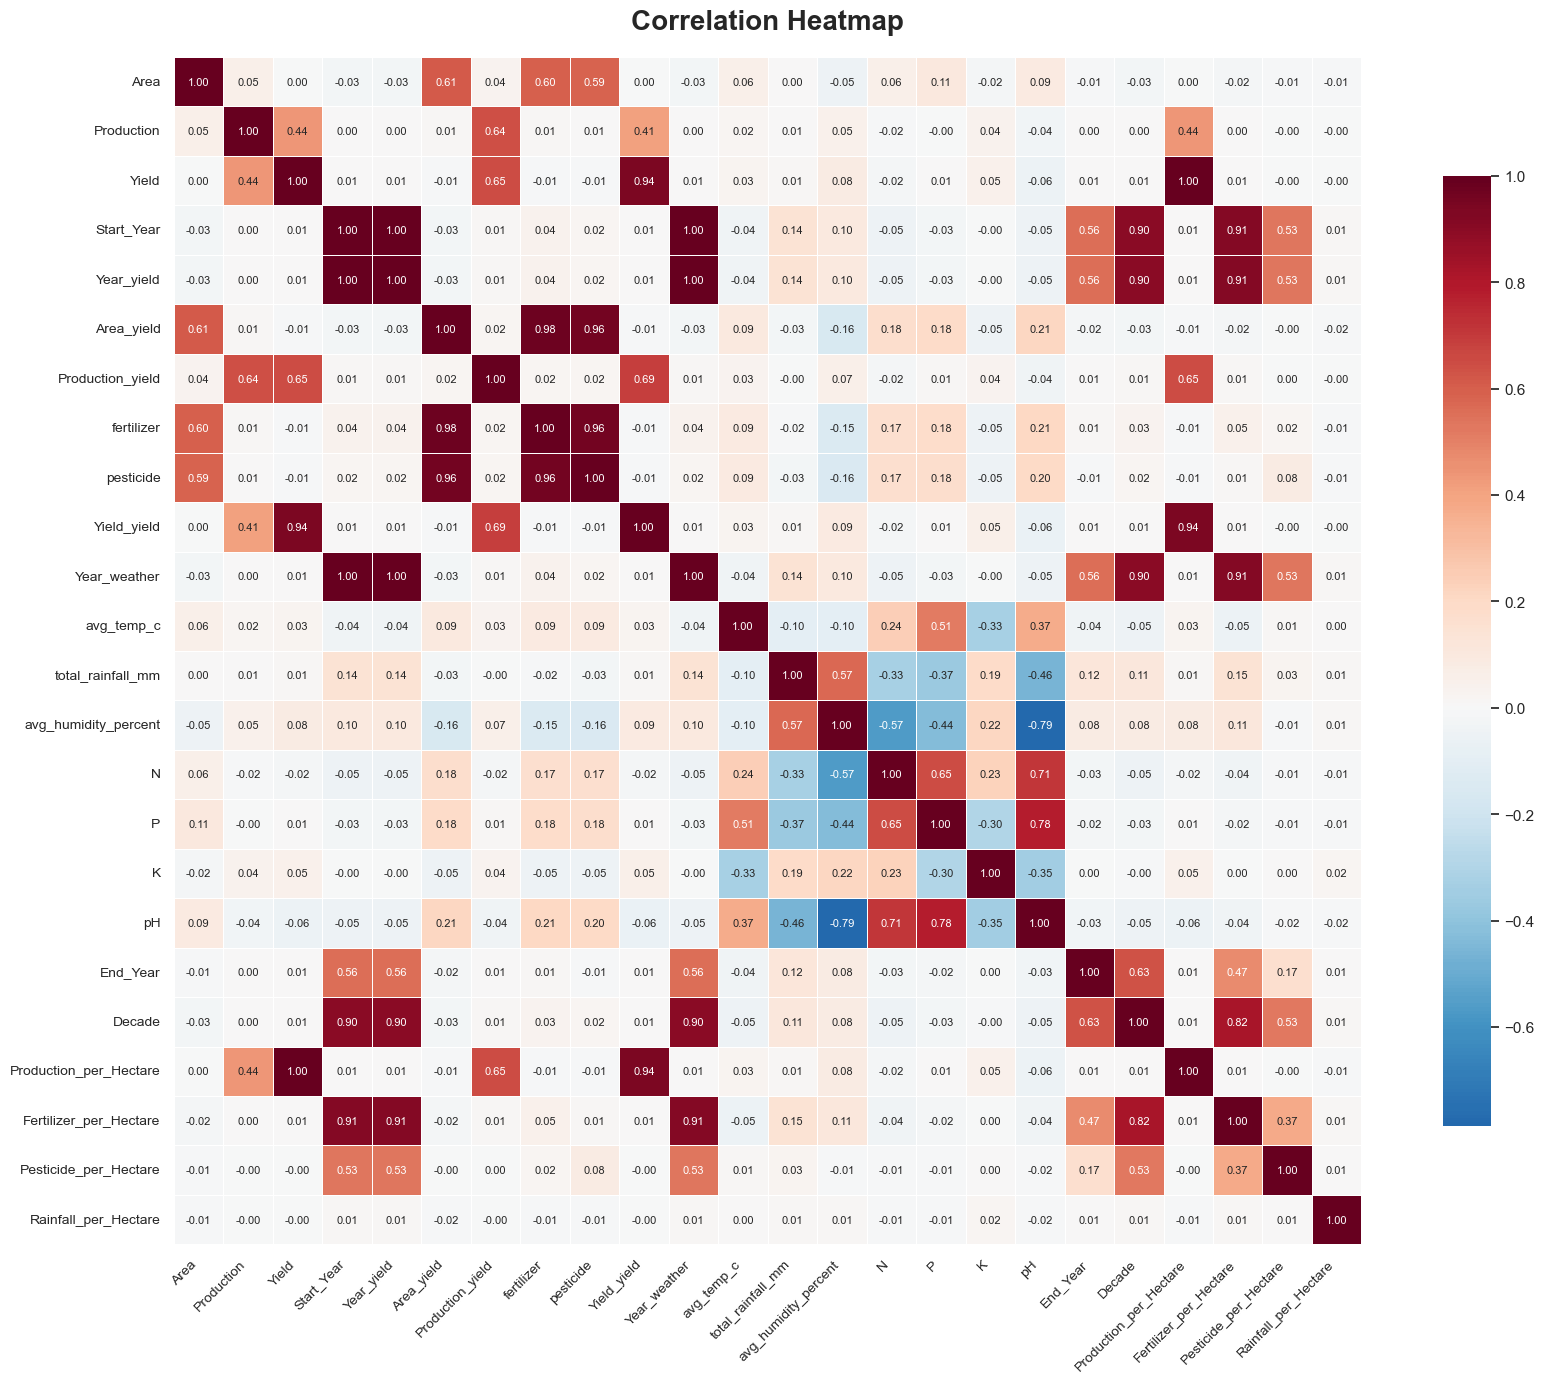

In [68]:
corr = weather.select_dtypes(include=np.number).corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    cmap="RdBu_r",          
    center=0,
    annot=True,            
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink":0.8},
    annot_kws={"size":8}
)

plt.title(
    "Correlation Heatmap",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [57]:
# 8C STATE ANALYSIS

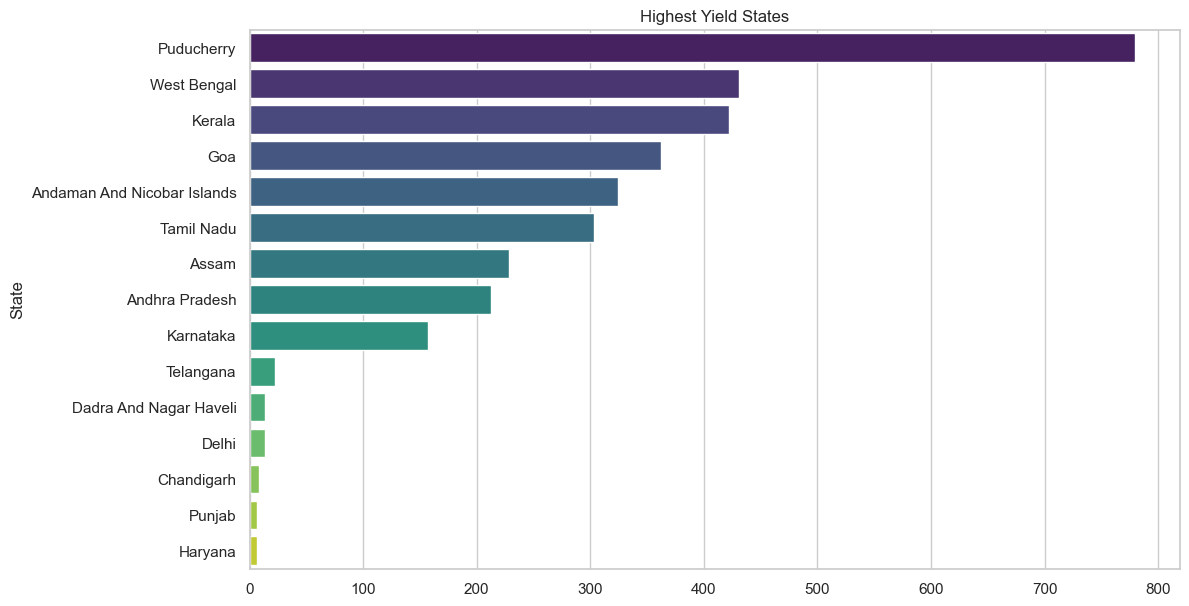

In [58]:
state_yield = (
    master.groupby("State")["Yield"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=state_yield.values,
    y=state_yield.index,
    palette="viridis"
)

plt.title("Highest Yield States")

plt.show()

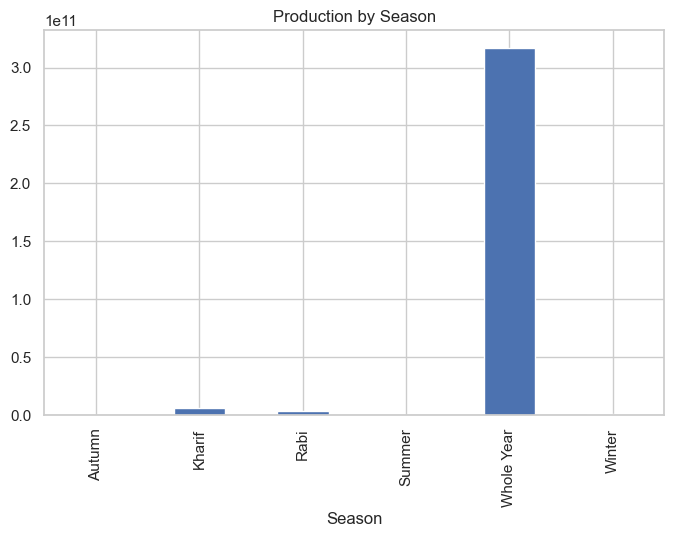

In [59]:
season = (
    master.groupby("Season")["Production"]
    .sum()
)

plt.figure(figsize=(8,5))

season.plot(kind="bar")

plt.title("Production by Season")

plt.show()

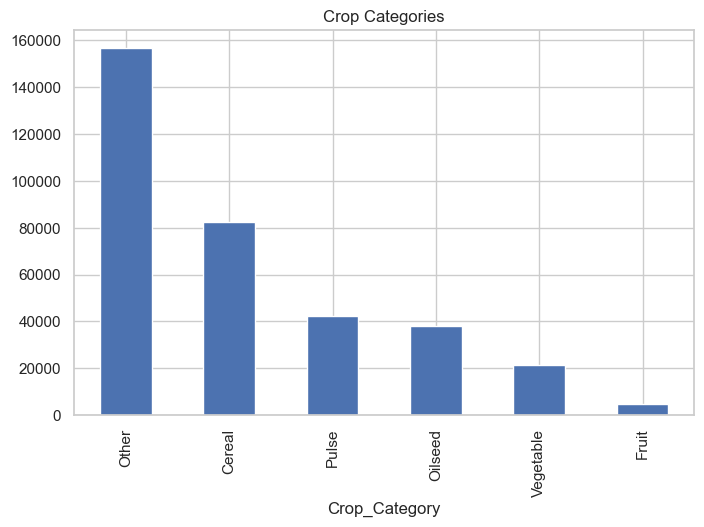

In [60]:
crop_category = (
    master["Crop_Category"]
    .value_counts()
)

plt.figure(figsize=(8,5))

crop_category.plot(kind="bar")

plt.title("Crop Categories")

plt.show()

In [61]:
# 8D RISK ANALYSIS

In [62]:
availability = pd.DataFrame({

    "Weather Available":[
        master["Weather_Data_Available"].sum()
    ],

    "Weather Missing":[
        (~master["Weather_Data_Available"]).sum()
    ],

    "Soil Available":[
        master["Soil_Data_Available"].sum()
    ],

    "Soil Missing":[
        (~master["Soil_Data_Available"]).sum()
    ]

})

availability

,Weather Available,Weather Missing,Soil Available,Soil Missing
0,323787,21587,323787,21587


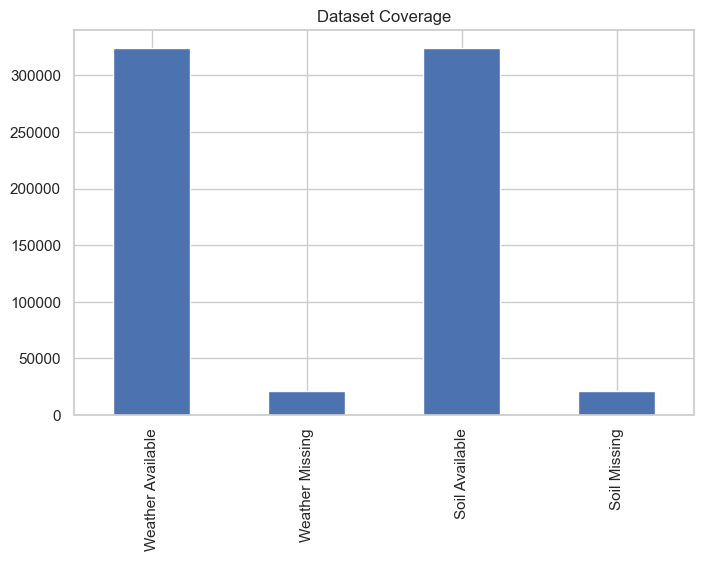

In [63]:
availability.T.plot(
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Dataset Coverage")

plt.show()

In [64]:
print("="*70)
print("PHASE 8 VERIFICATION")
print("="*70)

print("\nDataset Shape")
print(master.shape)

summary = pd.DataFrame({

    "Analysis":[

        "Business Insights",

        "Climate Analysis",

        "State Analysis",

        "Season Analysis",

        "Risk Analysis",

        "Verification"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "PASS"

    ]

})

display(summary)

PHASE 8 VERIFICATION

Dataset Shape
(345374, 40)


,Analysis,Status
0,Business Insights,Completed
1,Climate Analysis,Completed
2,State Analysis,Completed
3,Season Analysis,Completed
4,Risk Analysis,Completed
5,Verification,PASS
